# 02 - Demand Segmentation

This notebook reviews the Parquet outputs generated by `src/demand_segmentation.py`. It does not read the raw sales matrix and does not create the full long-format table.

## Business Goal

Classify item-store demand series by behavior, volume, and variability to decide where forecasting should start and which series require special inventory treatment.

In [1]:
from pathlib import Path
import os

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
os.environ.setdefault('MPLCONFIGDIR', str(PROJECT_ROOT / '.matplotlib'))

import pandas as pd
import matplotlib.pyplot as plt

PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
segmentation = pd.read_parquet(PROCESSED_DIR / 'demand_segmentation.parquet')
segment_summary = pd.read_parquet(PROCESSED_DIR / 'segment_summary.parquet')
abc_xyz_summary = pd.read_parquet(PROCESSED_DIR / 'abc_xyz_summary.parquet')
pattern_by_category = pd.read_parquet(PROCESSED_DIR / 'demand_pattern_by_category.parquet')
pattern_by_store = pd.read_parquet(PROCESSED_DIR / 'demand_pattern_by_store.parquet')

## Demand Pattern Distribution

,demand_pattern,series_count,total_demand,avg_mean_demand,avg_zero_demand_pct,avg_adi,avg_cv_squared,series_share_pct,demand_share_pct
0,Intermittent,23102,28045633,0.634601,73.660698,7.471253,0.286921,75.769105,42.690400
1,Lumpy,5911,18100365,1.600705,60.185249,4.095794,0.765909,19.386684,27.551948
2,Smooth,980,13074239,6.973895,13.762014,1.167519,0.360675,3.214169,19.901298
3,Erratic,497,6475172,6.810515,16.807484,1.206891,0.726201,1.630043,9.856354


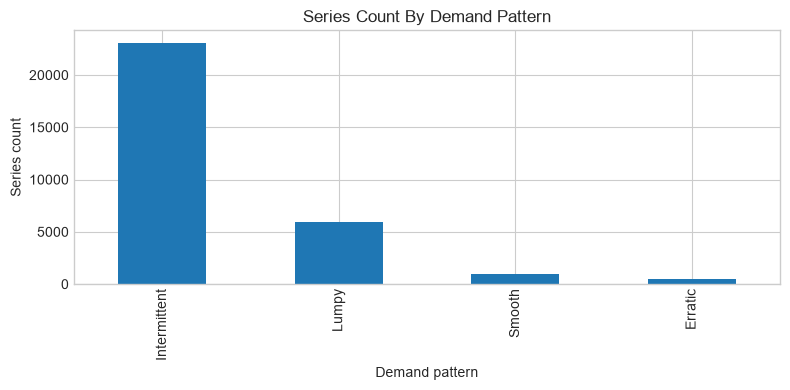

In [3]:
pattern_counts = segmentation['demand_pattern'].value_counts().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 4))
pattern_counts.plot(kind='bar', ax=ax, color='#1f77b4')
ax.set_title('Series Count By Demand Pattern')
ax.set_xlabel('Demand pattern')
ax.set_ylabel('Series count')
plt.tight_layout()
segment_summary

## ADI vs CV²

Syntetos-Boylan thresholds: ADI = 1.32 and CV² = 0.49.

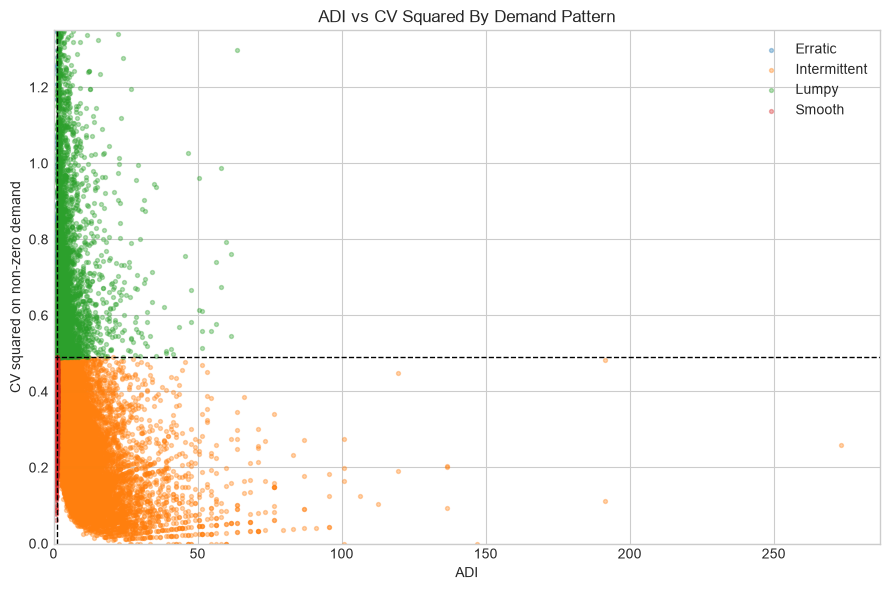

In [4]:
fig, ax = plt.subplots(figsize=(9, 6))
for pattern, group in segmentation.groupby('demand_pattern'):
    ax.scatter(group['adi'], group['cv_squared'], s=8, alpha=0.35, label=pattern)
ax.axvline(1.32, color='black', linestyle='--', linewidth=1)
ax.axhline(0.49, color='black', linestyle='--', linewidth=1)
ax.set_xlim(left=0)
ax.set_ylim(bottom=0, top=segmentation['cv_squared'].quantile(0.99))
ax.set_title('ADI vs CV Squared By Demand Pattern')
ax.set_xlabel('ADI')
ax.set_ylabel('CV squared on non-zero demand')
ax.legend()
plt.tight_layout()

## ABC-XYZ Matrix

,abc_class,xyz_class,abc_xyz_segment,series_count,total_demand,avg_zero_demand_pct,avg_coefficient_of_variation,series_share_pct,demand_share_pct
0,A,X,AX,77,3526955,0.824163,0.419475,0.252542,5.368648
1,A,Y,AY,1630,17143530,18.411930,0.852872,5.346015,26.095476
2,A,Z,AZ,7495,31885210,46.216049,1.419793,24.581830,48.534914
3,B,Z,BZ,9754,9854630,69.489838,1.967062,31.990817,15.000485
4,C,Z,CZ,11534,3285084,88.870850,3.597168,37.828796,5.000477


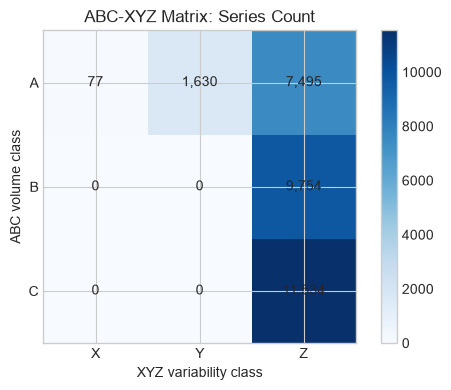

In [5]:
matrix = abc_xyz_summary.pivot(index='abc_class', columns='xyz_class', values='series_count').fillna(0).astype(int)
fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(matrix.values, cmap='Blues')
ax.set_xticks(range(len(matrix.columns)), matrix.columns)
ax.set_yticks(range(len(matrix.index)), matrix.index)
for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        ax.text(j, i, f'{matrix.values[i, j]:,}', ha='center', va='center')
ax.set_title('ABC-XYZ Matrix: Series Count')
ax.set_xlabel('XYZ variability class')
ax.set_ylabel('ABC volume class')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
abc_xyz_summary

## Demand Total By Segment

,total_demand
abc_xyz_segment,
AZ,31885210
AY,17143530
BZ,9854630
AX,3526955
CZ,3285084


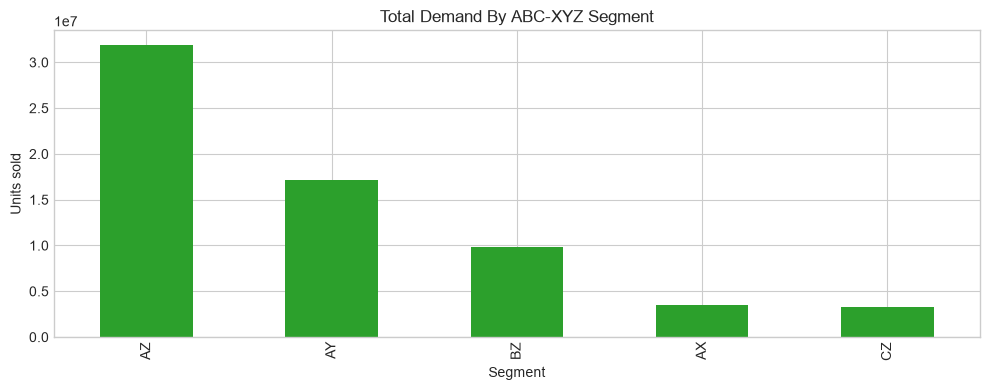

In [6]:
demand_by_segment = segmentation.groupby('abc_xyz_segment')['total_demand'].sum().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 4))
demand_by_segment.plot(kind='bar', ax=ax, color='#2ca02c')
ax.set_title('Total Demand By ABC-XYZ Segment')
ax.set_xlabel('Segment')
ax.set_ylabel('Units sold')
plt.tight_layout()
demand_by_segment.to_frame('total_demand')

## Zero-Demand Percentage By Pattern

,avg_zero_demand_pct
demand_pattern,
Intermittent,73.660698
Lumpy,60.185249
Erratic,16.807484
Smooth,13.762014


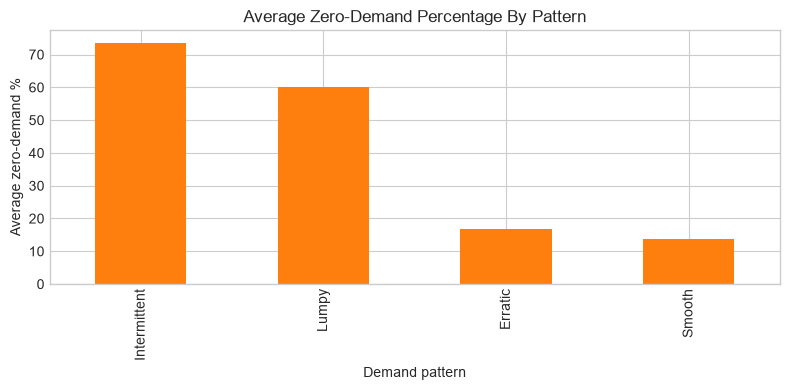

In [7]:
zero_by_pattern = segmentation.groupby('demand_pattern')['zero_demand_pct'].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 4))
zero_by_pattern.plot(kind='bar', ax=ax, color='#ff7f0e')
ax.set_title('Average Zero-Demand Percentage By Pattern')
ax.set_xlabel('Demand pattern')
ax.set_ylabel('Average zero-demand %')
plt.tight_layout()
zero_by_pattern.to_frame('avg_zero_demand_pct')

## Top Series By Volume Within Each Pattern

In [8]:
top_series_by_pattern = (
    segmentation.sort_values(['demand_pattern', 'total_demand'], ascending=[True, False])
    .groupby('demand_pattern')
    .head(5)
    [['demand_pattern', 'id', 'item_id', 'store_id', 'cat_id', 'dept_id', 'total_demand', 'adi', 'cv_squared', 'abc_xyz_segment']]
)
top_series_by_pattern

,demand_pattern,id,item_id,store_id,cat_id,dept_id,total_demand,adi,cv_squared,abc_xyz_segment
9127,Erratic,FOODS_3_808_CA_3_validation,FOODS_3_808,CA_3,FOODS,FOODS_3,72591,1.170747,0.530563,AY
8909,Erratic,FOODS_3_587_CA_3_validation,FOODS_3_587,CA_3,FOODS,FOODS_3,70324,1.101324,0.500687,AY
9003,Erratic,FOODS_3_681_CA_3_validation,FOODS_3_681,CA_3,FOODS,FOODS_3,55537,1.083239,0.600078,AY
30346,Erratic,FOODS_3_681_WI_3_validation,FOODS_3_681,WI_3,FOODS,FOODS_3,48163,1.115452,0.779653,AY
8641,Erratic,FOODS_3_319_CA_3_validation,FOODS_3_319,CA_3,FOODS,FOODS_3,46736,1.214603,0.557696,AY
2314,Intermittent,FOODS_3_090_CA_1_validation,FOODS_3_090,CA_1,FOODS,FOODS_3,127203,1.324792,0.326119,AY
29755,Intermittent,FOODS_3_090_WI_3_validation,FOODS_3_090,WI_3,FOODS,FOODS_3,121434,1.340575,0.307620,AY
17559,Intermittent,FOODS_3_090_TX_2_validation,FOODS_3_090,TX_2,FOODS,FOODS_3,119496,1.326630,0.318229,AY
20608,Intermittent,FOODS_3_090_TX_3_validation,FOODS_3_090,TX_3,FOODS,FOODS_3,114854,1.327550,0.236527,AY
14510,Intermittent,FOODS_3_090_TX_1_validation,FOODS_3_090,TX_1,FOODS,FOODS_3,93684,1.361566,0.383527,AY


## Business Conclusions

- Start forecasting with high-volume, lower-variability segments where accuracy improvements have the clearest operational payoff.
- Lumpy and high-zero series should not be forced into the same modeling strategy as smooth demand.
- ABC-XYZ segmentation can guide inventory policy: stable high-volume series need replenishment precision, while volatile high-volume series need exception monitoring and safety-stock review.